# CLUSTERING PRODUCTOS

## Justificación de las variables seleccionadas

El objetivo del clustering es agrupar productos con comportamiento similar para que la empresa
pueda tomar decisiones de negocio más informadas. Las variables seleccionadas se han elegido
pensando en las necesidades operativas del retailer:

- **Distribución de ventas por trimestre y región** (Q1–Q4 × Boston/NY/Philly): conocer en qué
trimestres y regiones se concentran las ventas de cada producto permite a la empresa anticipar
la demanda, optimizar el stock por almacén y planificar campañas de marketing estacionales.

- **Precio medio y coeficiente de variación del precio** (precio_cv): identificar productos con
precio estable vs productos con precio muy variable ayuda a diseñar estrategias de pricing
diferenciadas por grupo.

- **Descuento medio y primer descuento**: capturan la estrategia promocional de cada producto.
Productos que necesitan descuentos frecuentes o tempranos para venderse tienen un perfil de
demanda distinto a los que mantienen precio.

- **Ticket medio**: distingue productos de alto valor comprados con poca frecuencia de productos
baratos de alta rotación, dos perfiles con necesidades logísticas muy diferentes.

- **Coeficiente de variación de ventas** (ventas_cv): mide la irregularidad de la demanda.
Productos con demanda muy variable requieren más stock de seguridad que productos con ventas
estables.

- **% ventas en fin de semana y festivos**: permite identificar productos de consumo de ocio
o estacionales, útil para planificar refuerzos de stock en esos períodos.

- **Regionalidad**: un índice que mide si el producto se vende de forma homogénea en todas las
regiones o está concentrado en una. Relevante para decidir qué productos distribuir de forma
centralizada vs local.

In [1]:
import pandas as pd

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/data_dsmarket/'
except ImportError:
    DATA_PATH = 'data_dsmarket/'


df = pd.read_feather(DATA_PATH + 'df_preprocessed.feather')

Mounted at /content/drive


In [3]:
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df.head()

,id,item,category,department,store,store_code,region,d,sales,weekday,event,yearweek,sell_price,season,ingresos,is_holiday
date,,,,,,,,,,,,,,,,
2011-01-29,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_1,0,Saturday,None,201105.0,12.7414,Invierno,0.0,0
2011-01-30,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_2,0,Sunday,None,201105.0,12.7414,Invierno,0.0,0
2011-01-31,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_3,0,Monday,None,201105.0,12.7414,Invierno,0.0,0
2011-02-01,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_4,0,Tuesday,None,201105.0,12.7414,Invierno,0.0,0
2011-02-02,ACCESORIES_1_001_BOS_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,South_End,BOS_1,Boston,d_5,0,Wednesday,None,201105.0,12.7414,Invierno,0.0,0


Vamos a crear algunas variabels como porcentaje de ventas por region, precio medio por producto, unidades vendidas de cada producto

In [4]:
# para cada region separamos los datos, creamos una nueva columna 'quarter' que indica el trimestre del año, y luego usamos pd.crosstab para calcular la suma de las ventas totales por artículo y trimestre.
# Finalmente, renombramos las columnas para que sean más descriptivas y restablecemos el índice para que 'item' vuelva a ser una columna normal.
regions = df['region'].unique()
dfs = []
for region in regions:
    df_region = df[df['region'] == region].copy()
    df_region['quarter'] = df_region.index.quarter
    df_region = pd.crosstab(df_region['item'], df_region['quarter'], values=df_region['ingresos'], aggfunc='sum', normalize='index')
    df_region.columns = [f'{region}_Trimestre{col}' for col in df_region.columns]
    df_region.reset_index(inplace=True)
    dfs.append(df_region)

In [5]:
display(dfs[0])
display(dfs[1])
display(dfs[2])

,item,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4
0,ACCESORIES_1_001,0.261407,0.208852,0.229902,0.299840
1,ACCESORIES_1_002,0.205070,0.241527,0.260608,0.292795
2,ACCESORIES_1_003,0.266449,0.247798,0.285917,0.199837
3,ACCESORIES_1_004,0.262313,0.260763,0.231879,0.245044
4,ACCESORIES_1_005,0.212692,0.220332,0.266664,0.300312
...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.295176,0.179518,0.220741,0.304565
3045,SUPERMARKET_3_824,0.231428,0.277663,0.314298,0.176611
3046,SUPERMARKET_3_825,0.327716,0.257542,0.228880,0.185862
3047,SUPERMARKET_3_826,0.267169,0.296489,0.224461,0.211881


,item,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4
0,ACCESORIES_1_001,0.292514,0.182852,0.230936,0.293697
1,ACCESORIES_1_002,0.175182,0.190535,0.264493,0.369789
2,ACCESORIES_1_003,0.292750,0.247606,0.187415,0.272230
3,ACCESORIES_1_004,0.270005,0.255676,0.228044,0.246275
4,ACCESORIES_1_005,0.242563,0.202705,0.268171,0.286560
...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.284794,0.206293,0.276591,0.232322
3045,SUPERMARKET_3_824,0.230905,0.341688,0.225210,0.202197
3046,SUPERMARKET_3_825,0.279459,0.231081,0.289807,0.199653
3047,SUPERMARKET_3_826,0.249489,0.296864,0.250511,0.203136


,item,Philadelphia_Trimestre1,Philadelphia_Trimestre2,Philadelphia_Trimestre3,Philadelphia_Trimestre4
0,ACCESORIES_1_001,0.287250,0.192133,0.246951,0.273666
1,ACCESORIES_1_002,0.218956,0.177950,0.248356,0.354739
2,ACCESORIES_1_003,0.331651,0.256824,0.221132,0.190392
3,ACCESORIES_1_004,0.289951,0.262349,0.219520,0.228180
4,ACCESORIES_1_005,0.266457,0.193219,0.214482,0.325841
...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.310139,0.195423,0.223259,0.271178
3045,SUPERMARKET_3_824,0.228849,0.326637,0.283443,0.161072
3046,SUPERMARKET_3_825,0.327534,0.246164,0.226106,0.200195
3047,SUPERMARKET_3_826,0.215217,0.293422,0.249470,0.241891


In [6]:
# unimos los 3 dataframes resultantes en uno solo usando pd.merge, asegurándonos de mantener la columna 'item' como clave de unión. Luego, calculamos el total de unidades vendidas por 'item' y el precio medio total por 'item', y realizamos merges adicionales para agregar esta información al dataframe final.
df_merge = pd.merge(dfs[0], dfs[1], on='item', how='outer')
df_merge = pd.merge(df_merge, dfs[2], on='item', how='outer')

In [7]:
total_sales_by_item = df.groupby('item')['sales'].sum().reset_index(name='unidades vendidas')
average_price_by_item = df.groupby('item')['sell_price'].mean().reset_index(name='precio medio total')
df_merge = pd.merge(df_merge, total_sales_by_item, on='item', how='left')
df_final_item_region = pd.merge(df_merge, average_price_by_item, on='item', how='left')
df_final_item_region.head()

/tmp/ipykernel_10539/2607263752.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_sales_by_item = df.groupby('item')['sales'].sum().reset_index(name='unidades vendidas')
/tmp/ipykernel_10539/2607263752.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_price_by_item = df.groupby('item')['sell_price'].mean().reset_index(name='precio medio total')


,item,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4,Philadelphia_Trimestre1,Philadelphia_Trimestre2,Philadelphia_Trimestre3,Philadelphia_Trimestre4,unidades vendidas,precio medio total
0,ACCESORIES_1_001,0.261407,0.208852,0.229902,0.299840,0.292514,0.182852,0.230936,0.293697,0.287250,0.192133,0.246951,0.273666,4093,11.468528
1,ACCESORIES_1_002,0.205070,0.241527,0.260608,0.292795,0.175182,0.190535,0.264493,0.369789,0.218956,0.177950,0.248356,0.354739,5059,5.276737
2,ACCESORIES_1_003,0.266449,0.247798,0.285917,0.199837,0.292750,0.247606,0.187415,0.272230,0.331651,0.256824,0.221132,0.190392,1435,3.947623
3,ACCESORIES_1_004,0.262313,0.260763,0.231879,0.245044,0.270005,0.255676,0.228044,0.246275,0.289951,0.262349,0.219520,0.228180,39175,5.978931
4,ACCESORIES_1_005,0.212692,0.220332,0.266664,0.300312,0.242563,0.202705,0.268171,0.286560,0.266457,0.193219,0.214482,0.325841,14621,3.837978


In [8]:
# añadimos las ventas por trimestre en general para cada artículo, sin segmentar por región, y luego calculamos el precio medio total por artículo. Finalmente, realizamos merges adicionales para agregar esta información al dataframe final.
total_sales_by_quarter = (df.groupby(['item', df.index.quarter.rename('quarter')])['sales'].sum().unstack('quarter').rename(columns={1: 'Q1_total', 2: 'Q2_total', 3: 'Q3_total', 4: 'Q4_total'}).reset_index())
q_cols = ['Q1_total', 'Q2_total', 'Q3_total', 'Q4_total']
total_sales_by_quarter[q_cols] = total_sales_by_quarter[q_cols].div( total_sales_by_quarter[q_cols].sum(axis=1), axis=0)
df_final_item_region = pd.merge(df_final_item_region, total_sales_by_quarter, on='item', how='left')

/tmp/ipykernel_10539/149733055.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_sales_by_quarter = (df.groupby(['item', df.index.quarter.rename('quarter')])['sales'].sum().unstack('quarter').rename(columns={1: 'Q1_total', 2: 'Q2_total', 3: 'Q3_total', 4: 'Q4_total'}).reset_index())


In [9]:
df_final_item_region

,item,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4,Philadelphia_Trimestre1,Philadelphia_Trimestre2,Philadelphia_Trimestre3,Philadelphia_Trimestre4,unidades vendidas,precio medio total,Q1_total,Q2_total,Q3_total,Q4_total
0,ACCESORIES_1_001,0.261407,0.208852,0.229902,0.299840,0.292514,0.182852,0.230936,0.293697,0.287250,0.192133,0.246951,0.273666,4093,11.468528,0.284144,0.190569,0.232348,0.292939
1,ACCESORIES_1_002,0.205070,0.241527,0.260608,0.292795,0.175182,0.190535,0.264493,0.369789,0.218956,0.177950,0.248356,0.354739,5059,5.276737,0.202807,0.192924,0.255584,0.348686
2,ACCESORIES_1_003,0.266449,0.247798,0.285917,0.199837,0.292750,0.247606,0.187415,0.272230,0.331651,0.256824,0.221132,0.190392,1435,3.947623,0.294077,0.250174,0.221603,0.234146
3,ACCESORIES_1_004,0.262313,0.260763,0.231879,0.245044,0.270005,0.255676,0.228044,0.246275,0.289951,0.262349,0.219520,0.228180,39175,5.978931,0.270989,0.257792,0.228156,0.243063
4,ACCESORIES_1_005,0.212692,0.220332,0.266664,0.300312,0.242563,0.202705,0.268171,0.286560,0.266457,0.193219,0.214482,0.325841,14621,3.837978,0.238903,0.201423,0.253881,0.305793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.295176,0.179518,0.220741,0.304565,0.284794,0.206293,0.276591,0.232322,0.310139,0.195423,0.223259,0.271178,15388,3.345946,0.290421,0.195347,0.249480,0.264752
3045,SUPERMARKET_3_824,0.231428,0.277663,0.314298,0.176611,0.230905,0.341688,0.225210,0.202197,0.228849,0.326637,0.283443,0.161072,8325,3.026945,0.230390,0.322763,0.259580,0.187267
3046,SUPERMARKET_3_825,0.327716,0.257542,0.228880,0.185862,0.279459,0.231081,0.289807,0.199653,0.327534,0.246164,0.226106,0.200195,13526,4.934213,0.304894,0.240869,0.259944,0.194292
3047,SUPERMARKET_3_826,0.267169,0.296489,0.224461,0.211881,0.249489,0.296864,0.250511,0.203136,0.215217,0.293422,0.249470,0.241891,12188,1.535877,0.244585,0.295865,0.243764,0.215786


In [10]:
precio_stats = df.groupby('item')['sell_price'].agg(['mean', 'std']).reset_index()
precio_stats.columns = ['item', 'precio_medio', 'precio_std']
precio_stats['precio_cv'] = precio_stats['precio_std'] / precio_stats['precio_medio']

# Primer descuento (bajada >5% semana a semana)
precios_semanales = df.groupby(['item', df.index.to_period('W')])['sell_price'].mean().reset_index()
precios_semanales.columns = ['item', 'week', 'precio']
precios_semanales = precios_semanales.sort_values(['item', 'week'])
precios_semanales['precio_anterior'] = precios_semanales.groupby('item')['precio'].shift(1)
precios_semanales['descuento'] = (precios_semanales['precio_anterior'] - precios_semanales['precio']) / precios_semanales['precio_anterior']
precios_semanales['descuento'] = precios_semanales['descuento'].where(precios_semanales['descuento'] > 0.05, 0)

primer_descuento = (
    precios_semanales[precios_semanales['descuento'] > 0]
    .sort_values('week')
    .groupby('item')
    .first()
    .reset_index()[['item', 'descuento']]
    .rename(columns={'descuento': 'primer_descuento'})
)
primer_descuento['primer_descuento'] = primer_descuento['primer_descuento'].fillna(0)


/tmp/ipykernel_10539/265671365.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precio_stats = df.groupby('item')['sell_price'].agg(['mean', 'std']).reset_index()
/tmp/ipykernel_10539/265671365.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precios_semanales = df.groupby(['item', df.index.to_period('W')])['sell_price'].mean().reset_index()
/tmp/ipykernel_10539/265671365.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this wa

In [11]:
primer_descuento.sort_values('primer_descuento', ascending=False)

,item,primer_descuento
2934,SUPERMARKET_3_711,0.222222
3031,SUPERMARKET_3_810,0.208861
2849,SUPERMARKET_3_625,0.165433
2443,SUPERMARKET_3_219,0.156888
2254,SUPERMARKET_3_029,0.156888
...,...,...
1306,HOME_&_GARDEN_2_211,0.000000
1305,HOME_&_GARDEN_2_210,0.000000
1336,HOME_&_GARDEN_2_241,0.000000
1335,HOME_&_GARDEN_2_240,0.000000


In [12]:
precio_stats

,item,precio_medio,precio_std,precio_cv
0,ACCESORIES_1_001,11.468528,0.735440,0.064127
1,ACCESORIES_1_002,5.276737,0.090401,0.017132
2,ACCESORIES_1_003,3.947623,0.128106,0.032452
3,ACCESORIES_1_004,5.978931,0.277244,0.046370
4,ACCESORIES_1_005,3.837978,0.223108,0.058132
...,...,...,...,...
3044,SUPERMARKET_3_823,3.345946,0.225852,0.067500
3045,SUPERMARKET_3_824,3.026945,0.256036,0.084586
3046,SUPERMARKET_3_825,4.934213,0.241812,0.049007
3047,SUPERMARKET_3_826,1.535877,0.006426,0.004184


In [13]:
# Ticket medio (ingresos / nº semanas con ventas)
demanda = df.groupby(['item', df.index.to_period('W')]).agg(
    ventas=('sales', 'sum'),
    ingresos=('ingresos', 'sum')
).reset_index()

ticket_medio = (
    demanda[demanda['ventas'] > 0]
    .groupby('item')
    .apply(lambda x: x['ingresos'].sum() / len(x))
    .reset_index(name='ticket_medio')
)

ventas_cv = (
    demanda.groupby('item')['ventas']
    .agg(['mean', 'std'])
    .reset_index()
    .assign(ventas_cv=lambda x: x['std'] / x['mean'])[['item', 'ventas_cv']]
)

/tmp/ipykernel_10539/3181189352.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demanda = df.groupby(['item', df.index.to_period('W')]).agg(
/tmp/ipykernel_10539/3181189352.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('item')
/tmp/ipykernel_10539/3181189352.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this w

In [14]:
ventas_cv

,item,ventas_cv
0,ACCESORIES_1_001,1.028183
1,ACCESORIES_1_002,0.574104
2,ACCESORIES_1_003,1.470853
3,ACCESORIES_1_004,0.218073
4,ACCESORIES_1_005,0.463014
...,...,...
3044,SUPERMARKET_3_823,0.828115
3045,SUPERMARKET_3_824,0.679294
3046,SUPERMARKET_3_825,0.643982
3047,SUPERMARKET_3_826,0.905057


In [15]:
ticket_medio

,item,ticket_medio
0,ACCESORIES_1_001,310.605286
1,ACCESORIES_1_002,103.922470
2,ACCESORIES_1_003,51.421307
3,ACCESORIES_1_004,859.004456
4,ACCESORIES_1_005,214.104309
...,...,...
3044,SUPERMARKET_3_823,244.642319
3045,SUPERMARKET_3_824,104.166344
3046,SUPERMARKET_3_825,274.184967
3047,SUPERMARKET_3_826,117.000595


In [16]:
ventas_findes = df[df.index.weekday >= 5].groupby('item')['sales'].sum().reset_index(name='ventas_fines_semana')
# ventas_findes
ventas_total = df.groupby('item')['sales'].sum().reset_index(name='ventas_total')
porcentaje_findes = pd.merge(ventas_findes, ventas_total, on='item', how='left')
# porcentaje_findes
porcentaje_findes['porcentaje_findes'] = porcentaje_findes['ventas_fines_semana'] / porcentaje_findes['ventas_total']

/tmp/ipykernel_10539/3088306161.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_findes = df[df.index.weekday >= 5].groupby('item')['sales'].sum().reset_index(name='ventas_fines_semana')
/tmp/ipykernel_10539/3088306161.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_total = df.groupby('item')['sales'].sum().reset_index(name='ventas_total')


In [17]:
porcentaje_findes

,item,ventas_fines_semana,ventas_total,porcentaje_findes
0,ACCESORIES_1_001,1362,4093,0.332763
1,ACCESORIES_1_002,1777,5059,0.351255
2,ACCESORIES_1_003,544,1435,0.379094
3,ACCESORIES_1_004,14098,39175,0.359872
4,ACCESORIES_1_005,5250,14621,0.359073
...,...,...,...,...
3044,SUPERMARKET_3_823,5363,15388,0.348518
3045,SUPERMARKET_3_824,2768,8325,0.332492
3046,SUPERMARKET_3_825,4707,13526,0.347996
3047,SUPERMARKET_3_826,3745,12188,0.307269


In [18]:
ventas_festivos = df[df['is_holiday']== True].groupby('item')['sales'].sum().reset_index(name='ventas_festivos')
# ventas_festivos
ventas_total = df.groupby('item')['sales'].sum().reset_index(name='ventas_total')
porcentaje_festivos = pd.merge(ventas_festivos, ventas_total, on='item', how='left')
porcentaje_festivos['porcentaje_festivos'] = porcentaje_festivos['ventas_festivos'] / porcentaje_festivos['ventas_total']

/tmp/ipykernel_10539/324495656.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_festivos = df[df['is_holiday']== True].groupby('item')['sales'].sum().reset_index(name='ventas_festivos')
/tmp/ipykernel_10539/324495656.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_total = df.groupby('item')['sales'].sum().reset_index(name='ventas_total')


In [19]:
porcentaje_festivos.sort_values('porcentaje_festivos', ascending=False)

,item,ventas_festivos,ventas_total,porcentaje_festivos
3017,SUPERMARKET_3_796,204,2641,0.077243
2216,SUPERMARKET_2_390,116,1605,0.072274
1784,SUPERMARKET_1_176,560,7944,0.070493
2787,SUPERMARKET_3_563,131,1928,0.067946
1923,SUPERMARKET_2_096,87,1282,0.067863
...,...,...,...,...
1221,HOME_&_GARDEN_2_125,61,2435,0.025051
492,ACCESORIES_2_077,22,886,0.024831
611,HOME_&_GARDEN_1_049,116,4715,0.024602
1258,HOME_&_GARDEN_2_162,26,1182,0.021997


In [20]:
# unimos todos los dfs que hemos idio construyendo
df_final_item_region = pd.merge( df_final_item_region, precio_stats[['item', 'precio_std', 'precio_cv']], on='item', how='left') # ya teniamos la del precio medio
df_final_item_region = pd.merge(df_final_item_region, primer_descuento, on='item', how='left')
df_final_item_region = pd.merge(df_final_item_region, ticket_medio, on='item', how='left')
df_final_item_region = pd.merge(df_final_item_region, ventas_cv, on='item', how='left')
df_final_item_region = pd.merge(df_final_item_region, porcentaje_findes[['item', 'porcentaje_findes']], on='item', how='left')
df_final_item_region = pd.merge(df_final_item_region, porcentaje_festivos[['item', 'porcentaje_festivos']], on='item', how='left')
df_final_item_region

,item,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4,Philadelphia_Trimestre1,...,Q2_total,Q3_total,Q4_total,precio_std,precio_cv,primer_descuento,ticket_medio,ventas_cv,porcentaje_findes,porcentaje_festivos
0,ACCESORIES_1_001,0.261407,0.208852,0.229902,0.299840,0.292514,0.182852,0.230936,0.293697,0.287250,...,0.190569,0.232348,0.292939,0.735440,0.064127,0.000000,310.605286,1.028183,0.332763,0.053506
1,ACCESORIES_1_002,0.205070,0.241527,0.260608,0.292795,0.175182,0.190535,0.264493,0.369789,0.218956,...,0.192924,0.255584,0.348686,0.090401,0.017132,0.000000,103.922470,0.574104,0.351255,0.038941
2,ACCESORIES_1_003,0.266449,0.247798,0.285917,0.199837,0.292750,0.247606,0.187415,0.272230,0.331651,...,0.250174,0.221603,0.234146,0.128106,0.032452,0.067295,51.421307,1.470853,0.379094,0.054355
3,ACCESORIES_1_004,0.262313,0.260763,0.231879,0.245044,0.270005,0.255676,0.228044,0.246275,0.289951,...,0.257792,0.228156,0.243063,0.277244,0.046370,0.000000,859.004456,0.218073,0.359872,0.044365
4,ACCESORIES_1_005,0.212692,0.220332,0.266664,0.300312,0.242563,0.202705,0.268171,0.286560,0.266457,...,0.201423,0.253881,0.305793,0.223108,0.058132,0.071023,214.104309,0.463014,0.359073,0.044115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.295176,0.179518,0.220741,0.304565,0.284794,0.206293,0.276591,0.232322,0.310139,...,0.195347,0.249480,0.264752,0.225852,0.067500,0.057835,244.642319,0.828115,0.348518,0.043215
3045,SUPERMARKET_3_824,0.231428,0.277663,0.314298,0.176611,0.230905,0.341688,0.225210,0.202197,0.228849,...,0.322763,0.259580,0.187267,0.256036,0.084586,0.000000,104.166344,0.679294,0.332492,0.035195
3046,SUPERMARKET_3_825,0.327716,0.257542,0.228880,0.185862,0.279459,0.231081,0.289807,0.199653,0.327534,...,0.240869,0.259944,0.194292,0.241812,0.049007,0.062099,274.184967,0.643982,0.347996,0.043028
3047,SUPERMARKET_3_826,0.267169,0.296489,0.224461,0.211881,0.249489,0.296864,0.250511,0.203136,0.215217,...,0.295865,0.243764,0.215786,0.006426,0.004184,0.000000,117.000595,0.905057,0.307269,0.038070


In [21]:
ventas_region = df.groupby(['item', 'region'])['ingresos'].sum().reset_index()
ventas_region['ingresos_norm'] = ventas_region.groupby('item')['ingresos'].transform(lambda x: x / x.sum())
ventas_region_pivot = ventas_region.pivot(index='item', columns='region', values='ingresos_norm').reset_index()
ventas_region_pivot['regionalidad'] = ventas_region_pivot.iloc[:, 1:].max(axis=1) - ventas_region_pivot.iloc[:, 1:].min(axis=1)
regionalidad = ventas_region_pivot[['item', 'regionalidad']]

df_final_item_region = pd.merge(df_final_item_region, regionalidad, on='item', how='left')

/tmp/ipykernel_10539/1113671444.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_region = df.groupby(['item', 'region'])['ingresos'].sum().reset_index()
/tmp/ipykernel_10539/1113671444.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_region['ingresos_norm'] = ventas_region.groupby('item')['ingresos'].transform(lambda x: x / x.sum())




Regionalidad baja (~0) → producto de distribución uniforme, se puede gestionar de forma centralizada


Regionalidad alta (~1) → producto muy local, tiene sentido gestionar su stock de forma independiente por región



El más bajo que se ve es 0.07 → producto que se vende casi igual en las 3 regiones

Los más altos rondan 0.49 → producto donde una región vende casi el doble que otra

In [22]:
df_final_item_region

,item,Boston_Trimestre1,Boston_Trimestre2,Boston_Trimestre3,Boston_Trimestre4,New York_Trimestre1,New York_Trimestre2,New York_Trimestre3,New York_Trimestre4,Philadelphia_Trimestre1,...,Q3_total,Q4_total,precio_std,precio_cv,primer_descuento,ticket_medio,ventas_cv,porcentaje_findes,porcentaje_festivos,regionalidad
0,ACCESORIES_1_001,0.261407,0.208852,0.229902,0.299840,0.292514,0.182852,0.230936,0.293697,0.287250,...,0.232348,0.292939,0.735440,0.064127,0.000000,310.605286,1.028183,0.332763,0.053506,0.493571
1,ACCESORIES_1_002,0.205070,0.241527,0.260608,0.292795,0.175182,0.190535,0.264493,0.369789,0.218956,...,0.255584,0.348686,0.090401,0.017132,0.000000,103.922470,0.574104,0.351255,0.038941,0.337518
2,ACCESORIES_1_003,0.266449,0.247798,0.285917,0.199837,0.292750,0.247606,0.187415,0.272230,0.331651,...,0.221603,0.234146,0.128106,0.032452,0.067295,51.421307,1.470853,0.379094,0.054355,0.283080
3,ACCESORIES_1_004,0.262313,0.260763,0.231879,0.245044,0.270005,0.255676,0.228044,0.246275,0.289951,...,0.228156,0.243063,0.277244,0.046370,0.000000,859.004456,0.218073,0.359872,0.044365,0.416094
4,ACCESORIES_1_005,0.212692,0.220332,0.266664,0.300312,0.242563,0.202705,0.268171,0.286560,0.266457,...,0.253881,0.305793,0.223108,0.058132,0.071023,214.104309,0.463014,0.359073,0.044115,0.315161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3044,SUPERMARKET_3_823,0.295176,0.179518,0.220741,0.304565,0.284794,0.206293,0.276591,0.232322,0.310139,...,0.249480,0.264752,0.225852,0.067500,0.057835,244.642319,0.828115,0.348518,0.043215,0.522197
3045,SUPERMARKET_3_824,0.231428,0.277663,0.314298,0.176611,0.230905,0.341688,0.225210,0.202197,0.228849,...,0.259580,0.187267,0.256036,0.084586,0.000000,104.166344,0.679294,0.332492,0.035195,0.357495
3046,SUPERMARKET_3_825,0.327716,0.257542,0.228880,0.185862,0.279459,0.231081,0.289807,0.199653,0.327534,...,0.259944,0.194292,0.241812,0.049007,0.062099,274.184967,0.643982,0.347996,0.043028,0.191694
3047,SUPERMARKET_3_826,0.267169,0.296489,0.224461,0.211881,0.249489,0.296864,0.250511,0.203136,0.215217,...,0.243764,0.215786,0.006426,0.004184,0.000000,117.000595,0.905057,0.307269,0.038070,0.233635


In [23]:
df_final_item_region.isna().sum()

,0
item,0
Boston_Trimestre1,0
Boston_Trimestre2,0
Boston_Trimestre3,0
Boston_Trimestre4,0
New York_Trimestre1,0
New York_Trimestre2,0
New York_Trimestre3,0
New York_Trimestre4,0
Philadelphia_Trimestre1,0


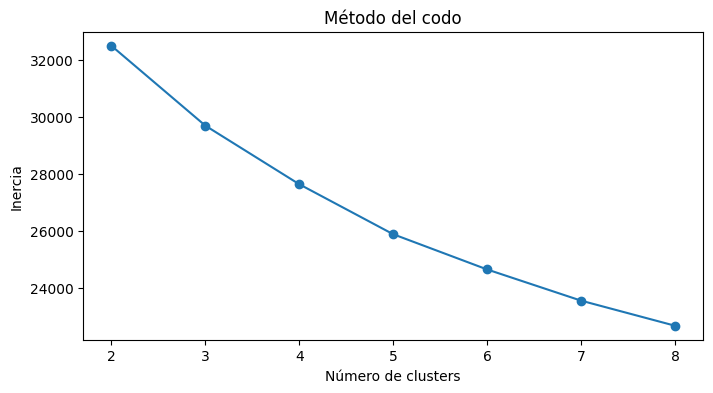

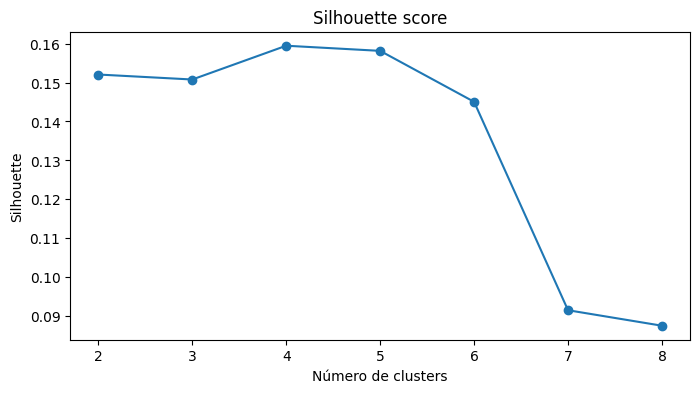

In [24]:
# ahora tendriamos que escalar las variables porque tenemos la del precio medio y cosas asi
from sklearn.preprocessing import StandardScaler
features = [
    'Q1_total', 'Q2_total', 'Q3_total', 'Q4_total',
    'precio medio total',
    'precio_cv',
    'primer_descuento',
    'ticket_medio',
    'ventas_cv',
    'porcentaje_findes',
    'porcentaje_festivos',
    'regionalidad'
]
# todavia meto las mas genericas y luego ya la de losporcentajes con regiones
X = df_final_item_region[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(K_range, silhouette, marker='o')
plt.title("Silhouette score")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.show()

Silhouette score con 4 clusters: 0.1527

Tamaño de cada cluster:
cluster
0     589
1     586
2    1681
3     193
Name: count, dtype: int64

Resumen de medias por cluster:


,Q1_total,Q2_total,Q3_total,Q4_total,precio medio total,precio_cv,primer_descuento,ticket_medio,ventas_cv,porcentaje_findes,porcentaje_festivos,regionalidad
cluster,,,,,,,,,,,,
0,0.31,0.21,0.20,0.27,7.05,0.03,0.00,365.399994,1.28,0.35,0.05,0.27
1,0.28,0.25,0.24,0.24,4.53,0.08,0.07,367.100006,0.68,0.34,0.04,0.27
2,0.27,0.25,0.25,0.24,5.38,0.03,0.00,339.670013,0.61,0.35,0.04,0.28
3,0.22,0.33,0.31,0.14,5.81,0.05,0.01,319.609985,1.02,0.35,0.04,0.33



Centroides aproximados en escala original:


,Q1_total,Q2_total,Q3_total,Q4_total,precio medio total,precio_cv,primer_descuento,ticket_medio,ventas_cv,porcentaje_findes,porcentaje_festivos,regionalidad
0,0.31,0.21,0.20,0.27,7.06,0.03,0.00,199.18,1.28,0.35,0.05,0.27
1,0.28,0.25,0.24,0.24,4.53,0.08,0.07,226.20,0.68,0.34,0.04,0.27
2,0.27,0.25,0.25,0.24,5.37,0.03,0.00,211.27,0.61,0.35,0.04,0.28
3,0.21,0.33,0.31,0.14,5.81,0.05,0.01,210.65,1.02,0.35,0.04,0.33


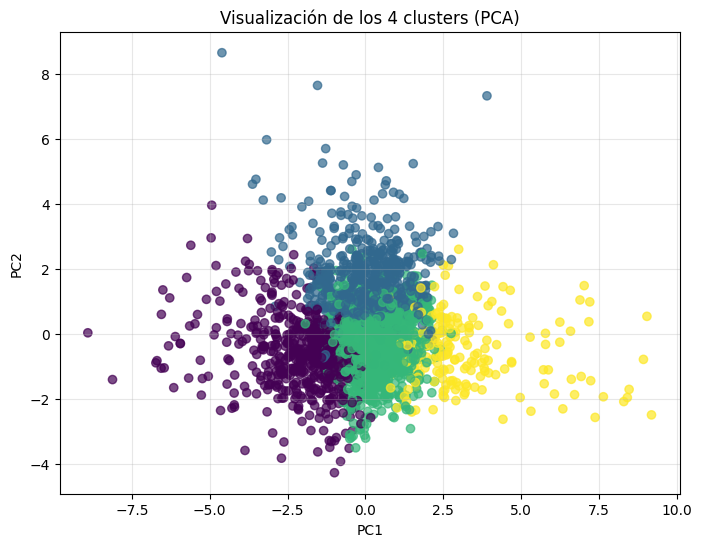


Ejemplo de asignación de productos a clusters:


,item,cluster
0,ACCESORIES_1_001,0
1,ACCESORIES_1_002,2
2,ACCESORIES_1_003,0
3,ACCESORIES_1_004,2
4,ACCESORIES_1_005,1
5,ACCESORIES_1_006,2
6,ACCESORIES_1_007,2
7,ACCESORIES_1_008,1
8,ACCESORIES_1_009,2
9,ACCESORIES_1_010,2


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# =========================
# 1. Selección de variables
# =========================
features = [
    'Q1_total',
    'Q2_total',
    'Q3_total',
    'Q4_total',
    'precio medio total',
    'precio_cv',
    'primer_descuento',
    'ticket_medio',
    'ventas_cv',
    'porcentaje_findes',
    'porcentaje_festivos',
    'regionalidad'
]

# Copia del dataset de trabajo
df_cluster = df_final_item_region.copy()

# =========================
# 2. Limpieza de datos
# =========================
X = df_cluster[features].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# Transformación logarítmica en variables con mucha escala
for col in ['Q1_total', 'Q2_total', 'Q3_total', 'Q4_total', 'ticket_medio']:
    if col in X.columns:
        X[col] = np.log1p(X[col])

# =========================
# 3. Escalado
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. Modelo KMeans con 4 clusters
# =========================
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=20)
labels_4 = kmeans_4.fit_predict(X_scaled)

df_cluster['cluster'] = labels_4

# Silhouette del modelo final
sil_score = silhouette_score(X_scaled, labels_4)
print(f"Silhouette score con 4 clusters: {sil_score:.4f}")

# =========================
# 5. Tamaño de los clusters
# =========================
print("\nTamaño de cada cluster:")
print(df_cluster['cluster'].value_counts().sort_index())

# =========================
# 6. Resumen de clusters
# =========================
resumen_clusters = df_cluster.groupby('cluster')[features].mean().round(2)
print("\nResumen de medias por cluster:")
display(resumen_clusters)

# =========================
# 7. Centroides desescalados
# =========================
centroides_scaled = kmeans_4.cluster_centers_
centroides_original = scaler.inverse_transform(centroides_scaled)
centroides_df = pd.DataFrame(centroides_original, columns=features)

# Deshacer log1p en las columnas transformadas
for col in ['Q1_total', 'Q2_total', 'Q3_total', 'Q4_total', 'ticket_medio']:
    if col in centroides_df.columns:
        centroides_df[col] = np.expm1(centroides_df[col])

centroides_df = centroides_df.round(2)

print("\nCentroides aproximados en escala original:")
display(centroides_df)

# =========================
# 8. Visualización PCA
# =========================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster['cluster'], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualización de los 4 clusters (PCA)')
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# 9. Productos por cluster
# =========================
columnas_mostrar = ['cluster']
if 'item' in df_cluster.columns:
    columnas_mostrar = ['item', 'cluster']

print("\nEjemplo de asignación de productos a clusters:")
display(df_cluster[columnas_mostrar].head(20))

In [26]:
# Perfil resumido de cada cluster
perfil = df_cluster.groupby('cluster')[features].agg(['mean', 'median']).round(2)
perfil.to_excel('perfil_clusters.xlsx')

In [27]:
perfil

Q1_total        Q2_total        Q3_total        Q4_total         \
            mean median     mean median     mean median     mean median   
cluster                                                                   
0           0.31   0.31     0.21   0.22     0.20   0.21     0.27   0.27   
1           0.28   0.27     0.25   0.25     0.24   0.24     0.24   0.24   
2           0.27   0.27     0.25   0.25     0.25   0.25     0.24   0.24   
3           0.22   0.22     0.33   0.32     0.31   0.30     0.14   0.14   

        precio medio total         ... ticket_medio             ventas_cv  \
                      mean median  ...         mean      median      mean   
cluster                            ...                                      
0                     7.05   4.85  ...   365.399994  198.639999      1.28   
1                     4.53   3.57  ...   367.100006  219.270004      0.68   
2                     5.38   4.28  ...   339.670013  208.080002      0.61   
3                     5.81   4.86  ...   319.609985  197.970001      1.02   

               porcentaje_findes        porcentaje_festivos         \
        median              mean median                mean median   
cluster                                                              
0         1.27              0.35   0.35                0.05   0.05   
1         0.63              0.34   0.34                0.04   0.04   
2         0.52              0.35   0.35                0.04   0.04   
3         0.93              0.35   0.35                0.04   0.04   

        regionalidad         
                mean median  
cluster                      
0               0.27   0.26  
1               0.27   0.26  
2               0.28   0.28  
3               0.33   0.32  

[4 rows x 24 columns]

"""
Cluster 0
Perfil
Muy fuerte en Q2 y Q3
Muy flojo en Q4
Precio medio intermedio: 5.96
Variabilidad de precio baja-moderada: 0.04
Primer descuento casi nulo: 0.01
Ticket medio relativamente bajo: 323.52
Variabilidad de ventas relativamente alta: 1.04
Regionalidad más alta que el resto: 0.33
Interpretación
Este cluster parece corresponder a productos estacionales de primavera-verano, con más peso en la parte central del año y bastante menos presencia en el cuarto trimestre.
Nombre posible
Estacionales Q2-Q3
Productos de temporada media
Productos con sesgo primavera-verano
Cluster 1
Perfil
Muy fuerte en Q1
También fuerte en Q4
Débil en Q2 y Q3
Precio medio más alto: 7.03
ticket_medio más alto: 369.57
ventas_cv más alto: 1.30
Sin descuento inicial relevante
Regionalidad baja-media: 0.27
Interpretación
Este cluster parece reunir productos con comportamiento más fuerte en los extremos del año, sobre todo en Q1 y también en Q4, además de ser los de mayor precio medio y mayor irregularidad en ventas.
Nombre posible
Estacionales Q1-Q4
Productos de campaña/invierno
Productos de mayor valor y demanda irregular
Cluster 2
Perfil
Reparto trimestral muy equilibrado: 0.27, 0.25, 0.25, 0.24
Precio medio medio: 5.35
Muy poco descuento
Ticket medio intermedio: 338.52
Menor variabilidad de ventas: 0.59
Regionalidad media: 0.28
Interpretación
Este es el cluster más claramente de productos estables durante todo el año.
No destacan ni por campañas, ni por descuentos, ni por variabilidad. Son los más regulares.
Nombre posible
Productos estables
Demanda regular anual
Core portfolio
Cluster 3
Perfil
También bastante equilibrado por trimestre
Precio medio más bajo: 4.53
Mayor variabilidad de precio: 0.08
Mayor primer descuento: 0.07
Ticket medio alto: 362.62
Variabilidad de ventas baja-moderada: 0.69
Interpretación
Este cluster parece agrupar productos más promocionales o sensibles al precio, porque combina:
precio medio más bajo
más variación de precio
mayor descuento inicial
No son tan estacionales, pero sí parecen más ligados a políticas comerciales o promociones.
Nombre posible
Productos promocionales
Productos sensibles al precio
Low price / promo
Resumen simple de los 4 clusters
Cluster 0: productos estacionales con pico en Q2-Q3
Cluster 1: productos estacionales con pico en Q1-Q4, más caros y más irregulares
Cluster 2: productos estables durante todo el año
Cluster 3: productos promocionales, más baratos y con mayor variabilidad de precio
"""

<Figure size 800x500 with 0 Axes>

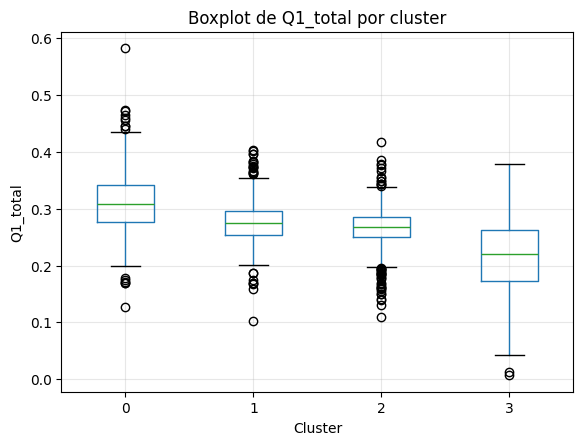

<Figure size 800x500 with 0 Axes>

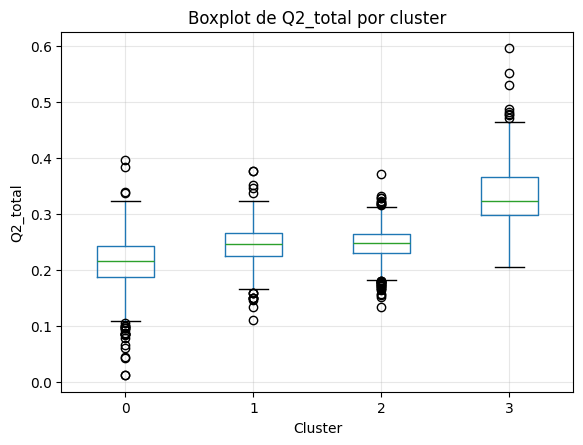

<Figure size 800x500 with 0 Axes>

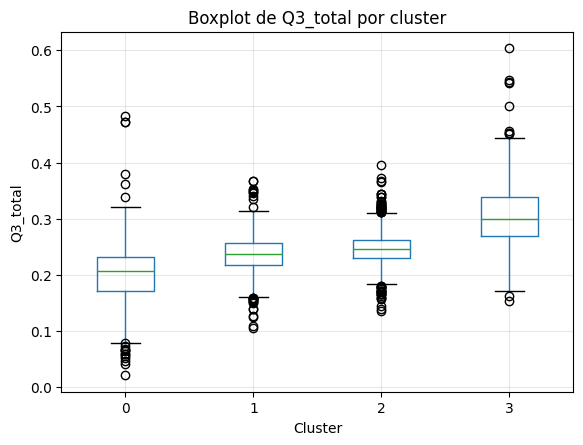

<Figure size 800x500 with 0 Axes>

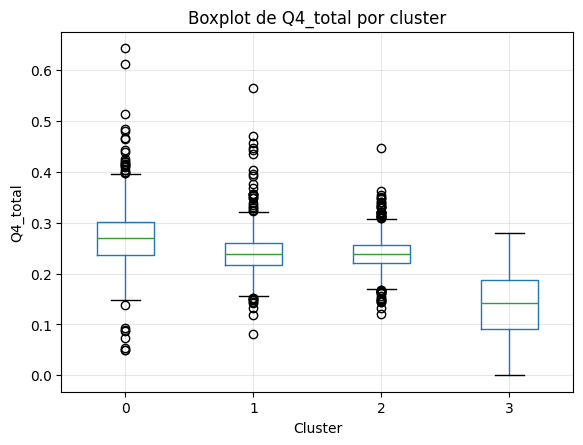

<Figure size 800x500 with 0 Axes>

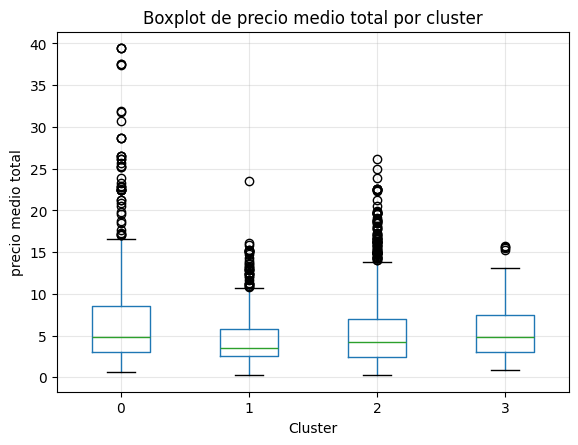

<Figure size 800x500 with 0 Axes>

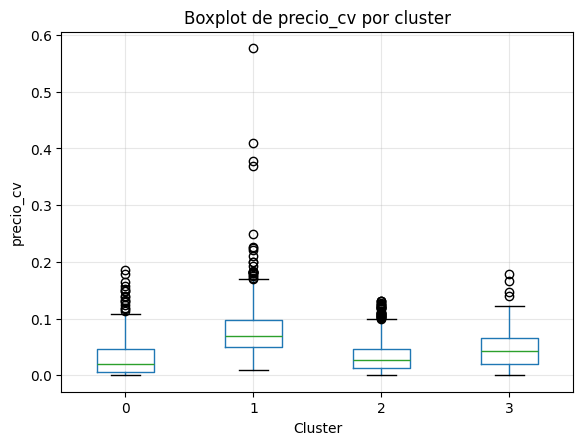

<Figure size 800x500 with 0 Axes>

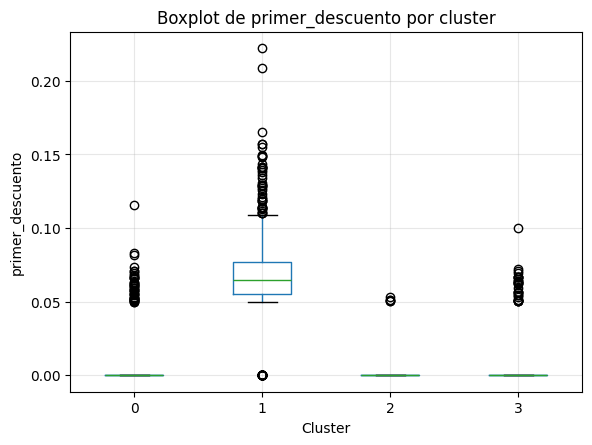

<Figure size 800x500 with 0 Axes>

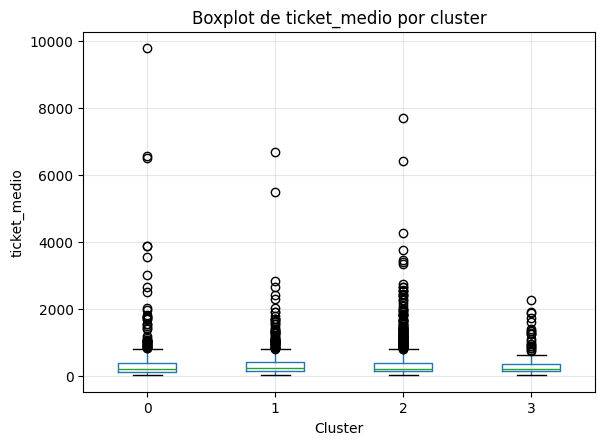

<Figure size 800x500 with 0 Axes>

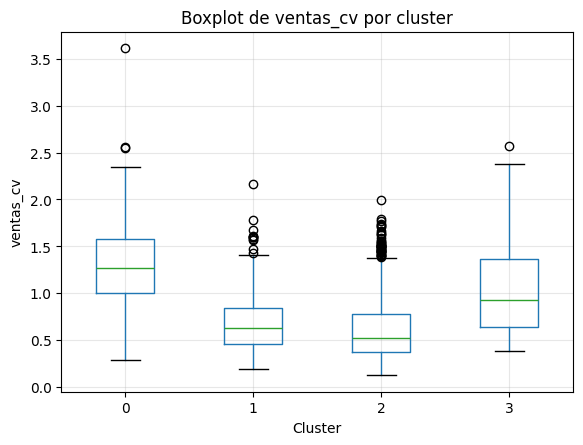

<Figure size 800x500 with 0 Axes>

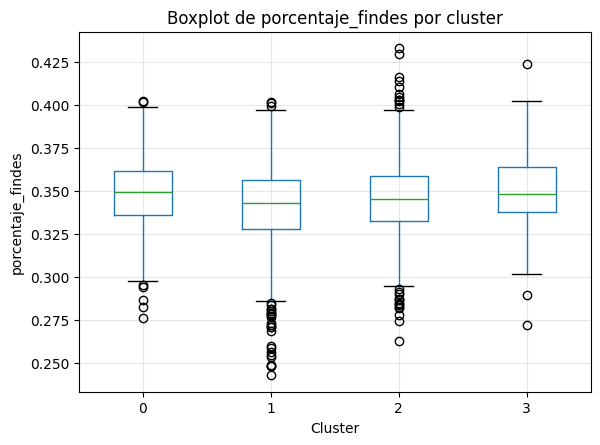

<Figure size 800x500 with 0 Axes>

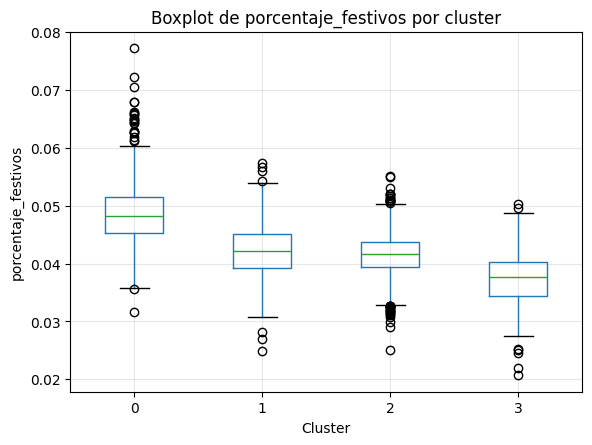

<Figure size 800x500 with 0 Axes>

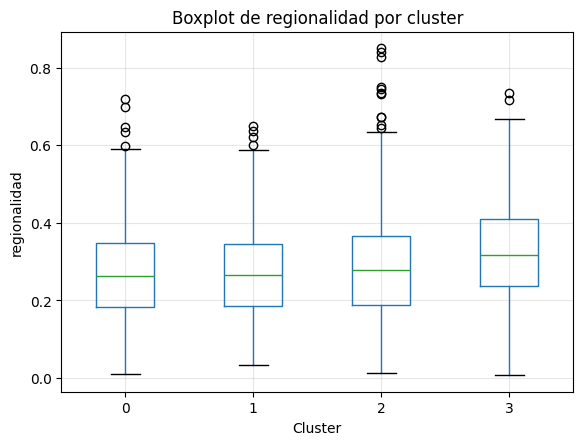

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

variables_boxplot = [
    'Q1_total',
    'Q2_total',
    'Q3_total',
    'Q4_total',
    'precio medio total',
    'precio_cv',
    'primer_descuento',
    'ticket_medio',
    'ventas_cv',
    'porcentaje_findes',
    'porcentaje_festivos',
    'regionalidad'
]

# Asegúrate de que este dataframe es el que tiene una fila por producto y la columna cluster
df_box = df_cluster.copy()

for var in variables_boxplot:
    plt.figure(figsize=(8, 5))
    df_box.boxplot(column=var, by='cluster')
    plt.title(f'Boxplot de {var} por cluster')
    plt.suptitle('')
    plt.xlabel('Cluster')
    plt.ylabel(var)
    plt.grid(alpha=0.3)
    plt.show()